In [1]:
import pandas as pd
import numpy as np
import dask.dataframe as dd
import matplotlib.pyplot as plt
import os
from glob import glob
from dask.array.image import imread

In [2]:
image_location = "../../images/NightSkyImages/"
ideal_df_location = "../../data/ideal_df.parquet"

In [3]:
ideal_df = pd.read_parquet(ideal_df_location)
images = imread(f"{image_location}/2019-09/*.JPG")

In [4]:
test_image = images[1000].compute()
test_image.shape, test_image.dtype

((480, 640, 3), dtype('uint8'))

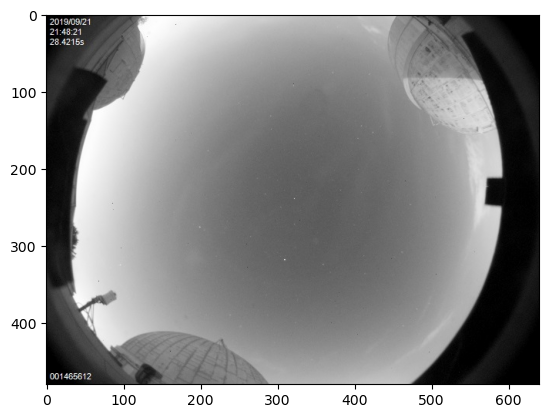

In [5]:
plt.imshow(test_image)

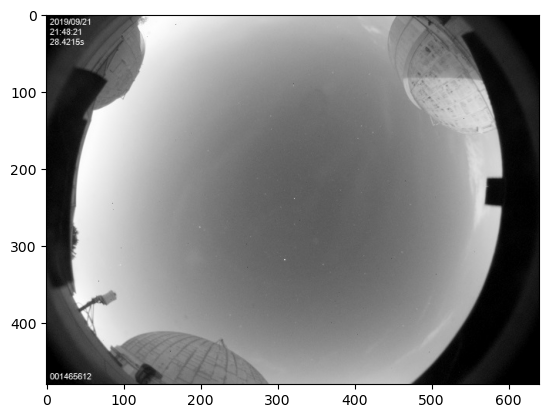

In [6]:
plt.imshow(test_image[:,:,0], cmap="gray")

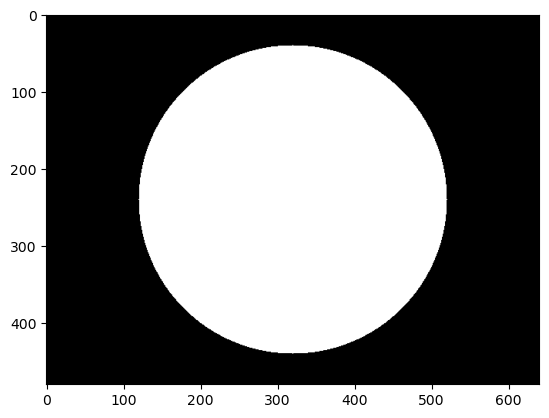

In [7]:
y, x = np.ogrid[:480, :640]
mask = ((x - 320) ** 2 + (y - 240) ** 2 <= 200 ** 2).astype(np.uint8)
plt.imshow(mask, cmap="gray")

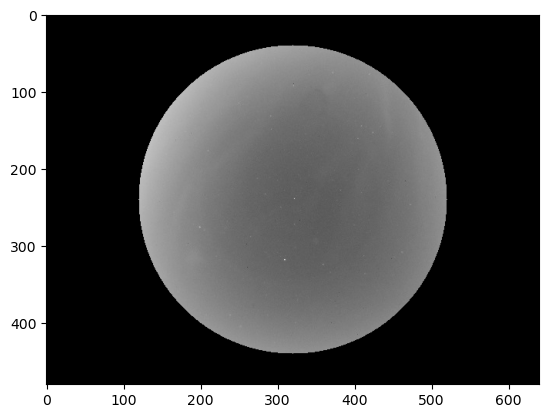

In [8]:
plt.imshow(mask[..., None] * test_image)

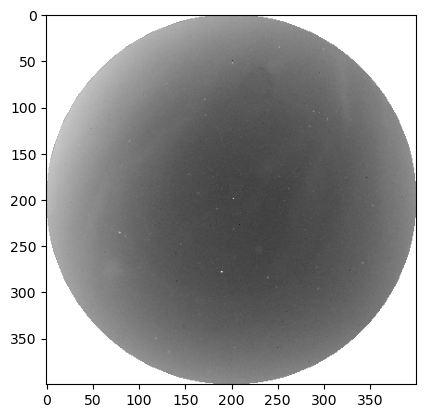

In [9]:
from allsky.analysis import mask_image

# plt.imshow(mask_image(test_image[:,:,0]), cmap="gray")
plt.imshow(mask_image(test_image)[:,:,0], cmap="gray")

In [10]:
np.mean(mask_image(test_image))

np.float64(124.29055059819943)

In [11]:
mask_image(test_image).shape

(400, 400, 3)

In [56]:
process_dd: dd.DataFrame = dd.read_parquet(ideal_df_location, split_row_groups=True).repartition(npartitions=1000)

ideal_df = pd.read_parquet(ideal_df_location)

record_set = set([
    f"{image_location}{source_file[:-8]}/AllSkyImage{filename}.JPG"
    for filename, source_file in ideal_df[["filename", 'source_file']].to_numpy()
])
image_set = set(list(glob(os.path.join(image_location, "20*-*/*.JPG"))))
paths_i_have = record_set.intersection(image_set)

In [13]:
def build_image_path(row) -> str:
    return (
        f"{image_location}"
        f"{row['source_file'][:-8]}/AllSkyImage{row['filename']}.JPG"
    )

In [15]:
image_paths = ideal_df[['source_file', 'filename']].apply(build_image_path, axis=1)
image_paths

8     /home/rainybyte/SomeSkyImages/2010-08/AllSkyIm...
9     /home/rainybyte/SomeSkyImages/2010-08/AllSkyIm...
10    /home/rainybyte/SomeSkyImages/2010-08/AllSkyIm...
11    /home/rainybyte/SomeSkyImages/2010-08/AllSkyIm...
12    /home/rainybyte/SomeSkyImages/2010-08/AllSkyIm...
                            ...                        
4     /home/rainybyte/SomeSkyImages/2026-03/AllSkyIm...
5     /home/rainybyte/SomeSkyImages/2026-03/AllSkyIm...
6     /home/rainybyte/SomeSkyImages/2026-03/AllSkyIm...
7     /home/rainybyte/SomeSkyImages/2026-03/AllSkyIm...
8     /home/rainybyte/SomeSkyImages/2026-03/AllSkyIm...
Length: 581805, dtype: object

In [16]:
do_i_have_these = image_paths.isin(paths_i_have)
image_paths = image_paths[do_i_have_these]
image_paths

8     /home/rainybyte/SomeSkyImages/2010-08/AllSkyIm...
9     /home/rainybyte/SomeSkyImages/2010-08/AllSkyIm...
10    /home/rainybyte/SomeSkyImages/2010-08/AllSkyIm...
11    /home/rainybyte/SomeSkyImages/2010-08/AllSkyIm...
12    /home/rainybyte/SomeSkyImages/2010-08/AllSkyIm...
                            ...                        
4     /home/rainybyte/SomeSkyImages/2026-03/AllSkyIm...
5     /home/rainybyte/SomeSkyImages/2026-03/AllSkyIm...
6     /home/rainybyte/SomeSkyImages/2026-03/AllSkyIm...
7     /home/rainybyte/SomeSkyImages/2026-03/AllSkyIm...
8     /home/rainybyte/SomeSkyImages/2026-03/AllSkyIm...
Length: 581805, dtype: object

In [17]:
result = ideal_df[do_i_have_these].assign(image_path=image_paths)
result

,date,time,exposure,filename,source_file,timestamp,image_path
8,2010/08/11,22:38:00,2.7883,000021274,2010-08.parquet,2010-08-11 22:38:00,/home/rainybyte/SomeSkyImages/2010-08/AllSkyIm...
9,2010/08/11,22:39:17,2.4769,000021275,2010-08.parquet,2010-08-11 22:39:17,/home/rainybyte/SomeSkyImages/2010-08/AllSkyIm...
10,2010/08/11,22:40:17,2.4769,000021276,2010-08.parquet,2010-08-11 22:40:17,/home/rainybyte/SomeSkyImages/2010-08/AllSkyIm...
11,2010/08/11,22:41:34,2.4769,000021277,2010-08.parquet,2010-08-11 22:41:34,/home/rainybyte/SomeSkyImages/2010-08/AllSkyIm...
12,2010/08/11,22:42:34,2.4769,000021278,2010-08.parquet,2010-08-11 22:42:34,/home/rainybyte/SomeSkyImages/2010-08/AllSkyIm...
...,...,...,...,...,...,...,...
4,2026/03/25,05:40:08,32.0241,000422467,2026-03.parquet,2026-03-25 05:40:08,/home/rainybyte/SomeSkyImages/2026-03/AllSkyIm...
5,2026/03/25,05:40:41,32.0241,000422468,2026-03.parquet,2026-03-25 05:40:41,/home/rainybyte/SomeSkyImages/2026-03/AllSkyIm...
6,2026/03/25,05:41:34,36.3559,000422469,2026-03.parquet,2026-03-25 05:41:34,/home/rainybyte/SomeSkyImages/2026-03/AllSkyIm...
7,2026/03/25,05:42:11,36.3559,000422470,2026-03.parquet,2026-03-25 05:42:11,/home/rainybyte/SomeSkyImages/2026-03/AllSkyIm...


In [62]:
def process_partition(df: pd.DataFrame) -> pd.DataFrame:
    image_paths = df[['source_file', 'filename']].apply(
        build_image_path,
        axis=1,
        # meta=("image_path", "object"),
    ).rename("image_path")

    do_i_have_these = image_paths.isin(paths_i_have)
    filtered_df = df[do_i_have_these]
    filtered_paths = image_paths[do_i_have_these]
    images = filtered_paths.apply(lambda path: np.squeeze(imread(path), axis=0)[:, :, 0])  # only the first channel
    masked_images = images.apply(mask_image)
    image_means = masked_images.apply(np.mean)
    image_sums = masked_images.apply(np.sum)
    image_mins = masked_images.apply(np.min)
    image_maxs = masked_images.apply(np.max)

    return filtered_df.assign(
        image_paths=filtered_paths,
        image_mean=image_means,
        image_sum=image_sums,
        image_min=image_mins,
        image_max=image_maxs,
    )


In [65]:
meta = pd.DataFrame({
    "date": pd.Series(dtype="object"),
    "time": pd.Series(dtype="object"),
    "exposure": pd.Series(dtype="float64"),
    "filename": pd.Series(dtype="object"),
    "source_file": pd.Series(dtype="object"),
    "timestamp": pd.Series(dtype="datetime64[ns]"),
    "image_paths": pd.Series(dtype="object"),
    "image_mean": pd.Series(dtype="float64"),
    "image_sum": pd.Series(dtype="float64"),
    "image_min": pd.Series(dtype="float64"),
    "image_max": pd.Series(dtype="float64"),
})

enriched_df = process_dd.map_partitions(process_partition, meta=meta).compute(scheduler="processes")
enriched_df

,date,time,exposure,filename,source_file,timestamp,image_paths,image_mean,image_sum,image_min,image_max
8,2010/08/11,22:38:00,2.7883,000021274,2010-08.parquet,2010-08-11 22:38:00,/home/rainybyte/SomeSkyImages/2010-08/AllSkyIm...,157.789822,19822662,105,242
9,2010/08/11,22:39:17,2.4769,000021275,2010-08.parquet,2010-08-11 22:39:17,/home/rainybyte/SomeSkyImages/2010-08/AllSkyIm...,159.858382,20082529,102,242
10,2010/08/11,22:40:17,2.4769,000021276,2010-08.parquet,2010-08-11 22:40:17,/home/rainybyte/SomeSkyImages/2010-08/AllSkyIm...,163.385713,20525657,115,240
11,2010/08/11,22:41:34,2.4769,000021277,2010-08.parquet,2010-08-11 22:41:34,/home/rainybyte/SomeSkyImages/2010-08/AllSkyIm...,166.985608,20977901,117,245
12,2010/08/11,22:42:34,2.4769,000021278,2010-08.parquet,2010-08-11 22:42:34,/home/rainybyte/SomeSkyImages/2010-08/AllSkyIm...,158.146314,19867447,99,248
...,...,...,...,...,...,...,...,...,...,...,...
4,2026/03/25,05:40:08,32.0241,000422467,2026-03.parquet,2026-03-25 05:40:08,/home/rainybyte/SomeSkyImages/2026-03/AllSkyIm...,103.790141,13038844,51,221
5,2026/03/25,05:40:41,32.0241,000422468,2026-03.parquet,2026-03-25 05:40:41,/home/rainybyte/SomeSkyImages/2026-03/AllSkyIm...,103.978412,13062496,57,235
6,2026/03/25,05:41:34,36.3559,000422469,2026-03.parquet,2026-03-25 05:41:34,/home/rainybyte/SomeSkyImages/2026-03/AllSkyIm...,107.699698,13529990,56,232
7,2026/03/25,05:42:11,36.3559,000422470,2026-03.parquet,2026-03-25 05:42:11,/home/rainybyte/SomeSkyImages/2026-03/AllSkyIm...,107.371680,13488782,59,253


In [66]:
enriched_df_location = "../../data/enriched_df.parquet"
enriched_df.to_parquet(enriched_df_location)